In [12]:
import numpy as np 
import matplotlib.pyplot as plt 

# 1-Problem

In [13]:
#Dataset
X = np.array([90, 130, 210, 300, 350, 420, 480, 530, 640, 710], dtype=float)
y = np.array([7.1, 10.9, 19.2, 28, 32.8, 39.9, 46.1, 51, 62.2, 68.9], dtype=float)

In [14]:
#Normalize X for stable gradient descent 
X_mean = np.mean(X)
X_std  = np.std(X)
X_norm = (X - X_mean) / X_std

In [15]:
#Hypothesis: h(x) = theta0 + theta1*x 
def predict(X, theta0, theta1): 
    return theta0 + theta1 * X 

In [16]:
# Cost Function: Mean Squared Error 
def compute_cost(X, y, theta0, theta1): 
    m = len(y) 
    predictions = predict(X, theta0, theta1)
    errors = predictions - y 
    return (1 / (2*m)) * np.sum(errors ** 2) 


In [17]:
#Gradient Descent 
def gradient_descent(X, y, theta0 = 0.0, theta1 = 0.0, alpha = 0.1, n_iter = 1000): 
    m = len(y) 
    cost_history = []
    for i in range(n_iter): 
        predictions = predict(X, theta0, theta1) 
        errors = predictions - y 
        #Partial Derivative
        d_theta0 = (1 / m) * np.sum(errors) 
        d_theta1 = (1 / m) * np.sum(errors * X) 
        # Simultaneous update 
        theta0 = theta0 - alpha * d_theta0 
        theta1 = theta1 - alpha * d_theta1 
        cost_history.append(compute_cost(X, y, theta0, theta1)) 
    return theta0, theta1, cost_history 

In [18]:
#Train 
theta0 , theta1, cost_history = gradient_descent(X_norm, y , alpha = 0.1, n_iter = 1000)
print(f" Trained parameters (normalized space): θ0 = {theta0: .4f}, θ1 = {theta1: .4f}")
print(f" Final cost: {cost_history[-1]: .6f}")

 Trained parameters (normalized space): θ0 =  36.6100, θ1 =  19.8214
 Final cost:  0.008443


In [19]:
# Predict on a new value
x_new = (800 - X_mean) / X_std 
price_pred = predict(x_new, theta0, theta1) 
print(f"Prediction for 800 m^2: {price_pred : .2f} (* 1000 USD)")

Prediction for 800 m^2:  78.00 (* 1000 USD)


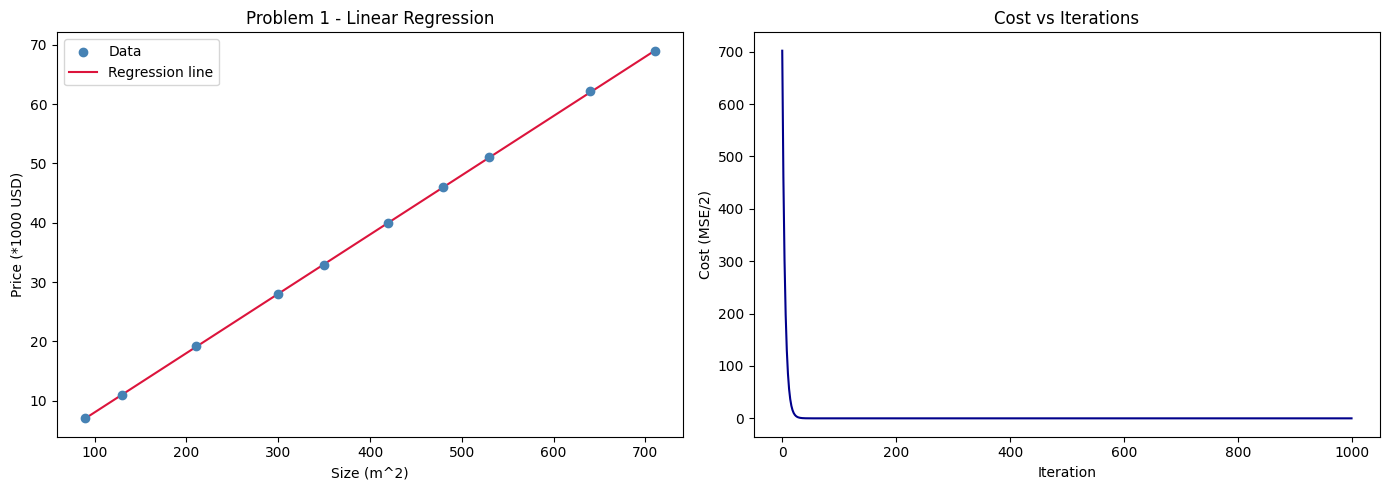

In [20]:
#Plot 
fig, axes = plt.subplots(1,2, figsize = (14, 5)) 
axes[0].scatter (X, y, color = 'steelblue', label = 'Data', zorder = 5) 
X_plot = np.linspace(X.min(), X.max(), 200) 
X_plot_norm = (X_plot - X_mean) / X_std 
axes[0].plot(X_plot, predict(X_plot_norm, theta0, theta1), color = 'crimson', label = 'Regression line')
axes[0].set_xlabel('Size (m^2)'); axes[0].set_ylabel('Price (*1000 USD)') 
axes[0].set_title('Problem 1 - Linear Regression')
axes[0].legend() 
axes[1].plot(cost_history, color ='darkblue') 
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Cost (MSE/2)') 
axes[1].set_title('Cost vs Iterations')
plt.tight_layout() 


# 2-Problem

In [21]:
import pandas as pd

In [22]:
df = pd.read_csv("land_price_1.csv")
land_area = df['land_area'].values 
dist_city = df['dist_to_city'].values 
price = df['price'].values 

print(f"Dataset: {len(price)} samples")
print(f"land_area range: {land_area.min():.0f} - {land_area.max():.0f} m^2")
print(f"dist_to_city range : {dist_city.min():.1f} - {dist_city.max():.1f} km")
print(f"price range :{price.min()} - {price.max()} (*1000 USD)") 


Dataset: 30 samples
land_area range: 122 - 3026 m^2
dist_to_city range : 0.1 - 19.7 km
price range :11.3 - 324.7 (*1000 USD)


In [23]:
#Normalize features 
la_mean, la_std = land_area.mean(), land_area.std() 
dc_mean, dc_std = dist_city.mean(), dist_city.std() 
la_norm = (land_area - la_mean) / la_std
dc_norm = (dist_city - dc_mean) / dc_std


In [ ]:
# Feature matrix [1, land_area, dist_to_city]
X2 = np.column_stack([np.ones(len(price)), la_norm, dc_norm])
theta2 = np.zeros(3) 
alpha2, n_iter2 = 0.1, 2000 
m2 = len(price) 
cost_hist2 = []
for _ in range(n_iter2): 
    errors = X2 @ theta2 - price 
    theta2 -= (alpha2 /m2) * (X2.T @ errors)
    cost_hist2.append((1 / (2 * m2)) * np.dot(errors, errors))
print(f"θ0 = {theta2[0]:.4f}")
print(f'θ1 (land_area) = {theta2[1]:.4f}')
print(f"θ2 (dist_to_city) = {theta2[2]:.4f}")
print(f"Final cost: {cost_hist2[-1]:.6f}")

θ0 = 164.7533
θ1 (land_area) = 86.7078
θ2 (dist_to_city) = -12.2158
Final cost: 0.182237


In [25]:
#Normal equation verification 
theta2_normal = np.linalg.pinv(X2.T @ X2) @ X2.T @ price
print(f" Normal equation : θ = {theta2_normal}")

 Normal equation : θ = [164.75333333  86.70784549 -12.21575569]


In [26]:
#Predict 
la_ex = (1500 - la_mean)/ la_std
dc_ex = (10 - dc_mean)/ dc_std
pred2 = theta2[0] + theta2[1]*la_ex + theta2[2] * dc_ex 
print(f" Exmaple - land_area = 1500 m^2 , dist = 10km then price ≈ {pred2:.2f} (*1000 USD)") 

 Exmaple - land_area = 1500 m^2 , dist = 10km then price ≈ 160.07 (*1000 USD)


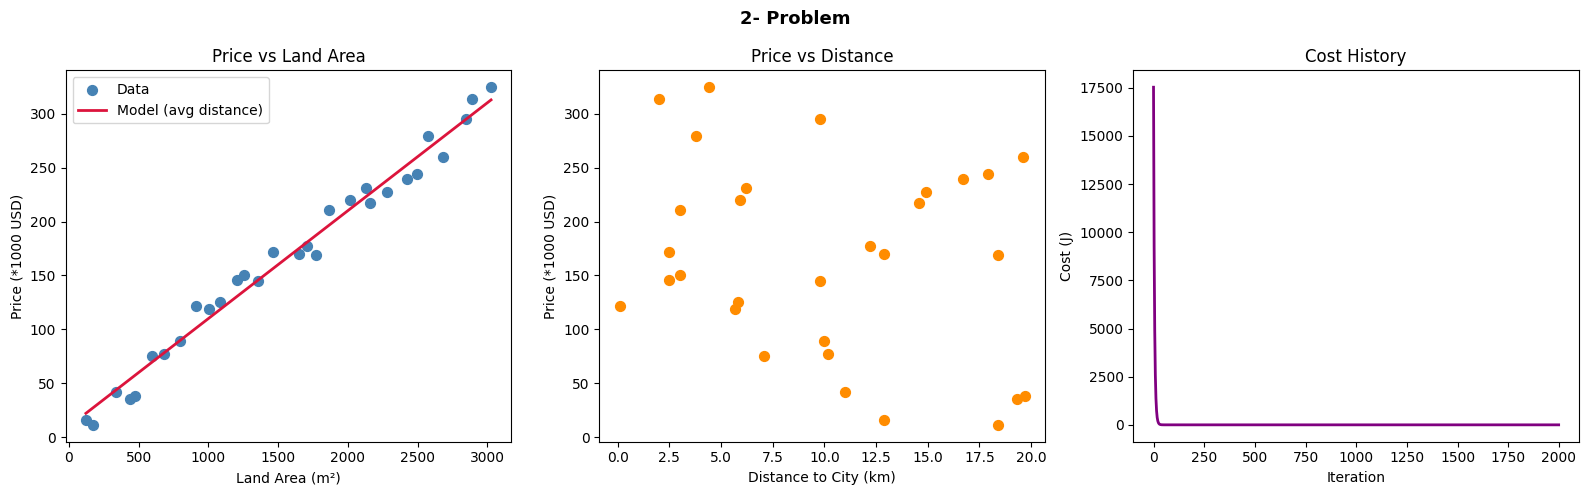

In [27]:
#Plot 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("2- Problem", fontsize=13, fontweight='bold')
axes[0].scatter(land_area, price, color='steelblue', s=50, label='Data')
la_line = np.linspace(land_area.min(), land_area.max(), 200)
la_line_n = (la_line - la_mean) / la_std
dc_avg_n = 0.0  # at mean distance
axes[0].plot(la_line, theta2[0] + theta2[1]*la_line_n + theta2[2]*dc_avg_n,
             color='crimson', lw=2, label='Model (avg distance)')
axes[0].set_xlabel('Land Area (m²)'); axes[0].set_ylabel('Price (*1000 USD)')
axes[0].set_title('Price vs Land Area'); axes[0].legend()
axes[1].scatter(dist_city, price, color='darkorange', s=50)
axes[1].set_xlabel('Distance to City (km)'); axes[1].set_ylabel('Price (*1000 USD)')
axes[1].set_title('Price vs Distance')
axes[2].plot(cost_hist2, color='purple', lw=2)
axes[2].set_xlabel('Iteration'); axes[2].set_ylabel('Cost (J)')
axes[2].set_title('Cost History')
plt.tight_layout()

# 3- Problem 

In [28]:
df3 = pd.read_csv("land_price_2.csv")
x3     = df3['land_area'].values
price3 = df3['price'].values
print(f"Dataset: {len(price3)} samples")
print(f"x range: {x3.min():.0f} - {x3.max():.0f}")
print(f"price range: {price3.min()} - {price3.max()}")

Dataset: 30 samples
x range: 129 - 3001
price range: 140.9 - 1793.6


In [29]:
#Build features: x and sqr x, then normalize each 
sqrt_x3 = np.sqrt(x3)
x3_mean,  x3_std  = x3.mean(),     x3.std()
sq3_mean, sq3_std = sqrt_x3.mean(), sqrt_x3.std()
x3_norm  = (x3     - x3_mean)  / x3_std
sq3_norm = (sqrt_x3 - sq3_mean) / sq3_std

In [30]:
#Feature matrix: [1, x, sqr x]
X3 = np.column_stack([np.ones(len(x3)), x3_norm, sq3_norm])
theta3 = np.zeros(3)
alpha3, n_iter3 = 0.1, 3000
m3 = len(price3)
cost_hist3 = []
for _ in range(n_iter3):
    errors = X3 @ theta3 - price3
    theta3 -= (alpha3 / m3) * (X3.T @ errors)
    cost_hist3.append((1/(2*m3)) * np.dot(errors, errors))

print(f"θ0 = {theta3[0]:.4f}")
print(f"θ1 (x)  = {theta3[1]:.4f}")
print(f"θ2 (sqrx) = {theta3[2]:.4f}")
print(f"Final cost: {cost_hist3[-1]:.6f}")

# R^2 score
y_pred3 = X3 @ theta3
ss_res = np.sum((price3 - y_pred3)**2)
ss_tot = np.sum((price3 - price3.mean())**2)
r2_3 = 1 - ss_res / ss_tot
print(f"R^2 = {r2_3:.6f}")

θ0 = 977.6533
θ1 (x)  = 437.0688
θ2 (sqrx) = 57.5761
Final cost: 14.856234
R^2 = 0.999878


In [31]:
#Comparison: linear-only vs with sqr x
X3_linear = np.column_stack([np.ones(len(x3)), x3_norm])
theta3_lin = np.linalg.pinv(X3_linear.T @ X3_linear) @ X3_linear.T @ price3
y_pred_lin = X3_linear @ theta3_lin
r2_lin = 1 - np.sum((price3 - y_pred_lin)**2) / ss_tot
print(f"Comparison — Linear only R^2: {r2_lin:.6f} vs With  sqr x R^2: {r2_3:.6f}")


Comparison — Linear only R^2: 0.999543 vs With  sqr x R^2: 0.999878


Text(0.5, 1.0, 'Cost History')

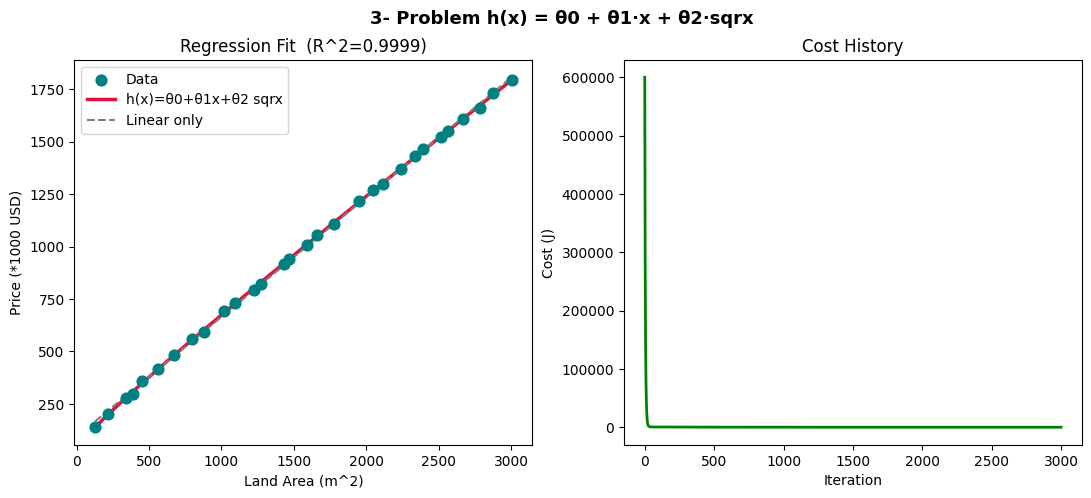

In [32]:
#plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("3- Problem h(x) = θ0 + θ1·x + θ2·sqrx", fontsize=13, fontweight='bold')
x_line = np.linspace(x3.min(), x3.max(), 300)
x_line_n  = (x_line - x3_mean) / x3_std
sq_line_n = (np.sqrt(x_line) - sq3_mean) / sq3_std
y_line    = theta3[0] + theta3[1]*x_line_n + theta3[2]*sq_line_n
y_line_l  = theta3_lin[0] + theta3_lin[1]*x_line_n
axes[0].scatter(x3, price3, color='teal', s=60, zorder=5, label='Data')
axes[0].plot(x_line, y_line,   color='crimson', lw=2.5, label='h(x)=θ0+θ1x+θ2 sqrx')
axes[0].plot(x_line, y_line_l, color='gray',    lw=1.5, linestyle='--', label='Linear only')
axes[0].set_xlabel('Land Area (m^2)'); axes[0].set_ylabel('Price (*1000 USD)')
axes[0].set_title(f'Regression Fit  (R^2={r2_3:.4f})')
axes[0].legend()
axes[1].plot(cost_hist3, color='green', lw=2)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Cost (J)')
axes[1].set_title('Cost History')